In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
#import url.request

In [18]:
#한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

#경고문 패치
import warnings

warnings.filterwarnings('ignore')

In [19]:
# 이미지 픽셀 값 : 0 ~255 => 0 ~ 1 로 변경 : 정규화
img= plt.imread('./data/dog.jpg')
print('이미지 크기', img.shape)

이미지 크기 (1213, 1546, 3)


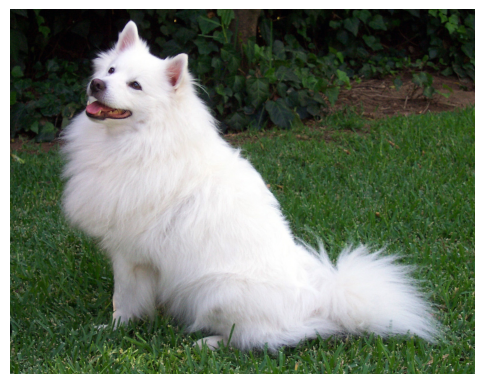

In [20]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.show()

## convolution(합성곱) = CNN의 눈

- 작은 필터(3x3 숫자판)가 이미지를 훑으며 feature패턴(테두리, 선)에 반응함
- CNN은 이런 필터를 수백개를 스스로 학습해서 물체를 탐지

In [21]:
img.shape

(1213, 1546, 3)

In [22]:
gray = tf.image.rgb_to_grayscale(img[np.newaxis].astype('float32'))

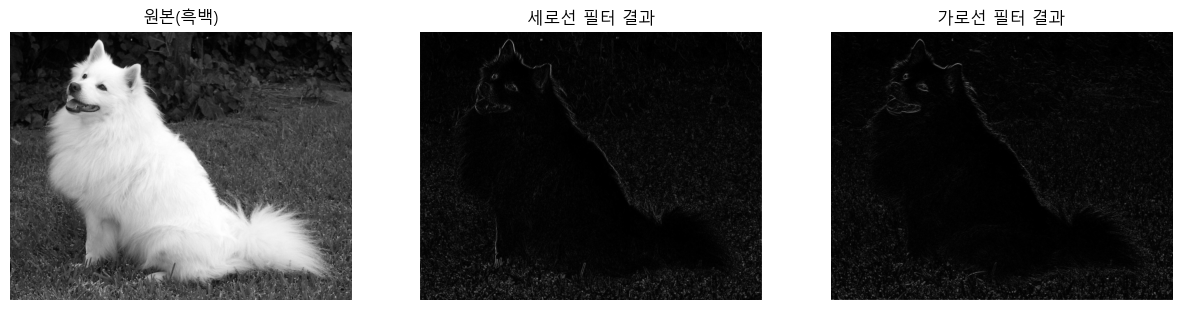

In [23]:
# plt.imread() 이미지를 읽을 경우 BGR이 아니라 RGB, cv2.imread()의 경우 BGR
# RGB 컬러 이미지를 흑백이미지로 변환
# np.newaxis : 이미지 1장 이라는 배치 차원 추가
# astype('float32') : tensorflow 계산을 위해서 실수형으로 변환
gray = tf.image.rgb_to_grayscale(img[np.newaxis].astype('float32'))  # 흑백+배치차원

# 세로선 필터 / 가로선 필터 (Sobel)
# 왼쪽과 오른쪽의 밝기 차이를 계산해서 새로 경계선을 찾음

# 3x3 크기의 필터 1개를 흑백 이미지에 적용
k_세로 = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], np.float32).reshape(3,3,1,1) # reshape(3,3,1,1) : 필터 세로크기(높이), 필터 가로크기(너비),
                                                                             #입력 채널 수(흑백이미지 : 1) , 출력 채널 수(출력필터수)
k_가로 = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], np.float32).reshape(3,3,1,1)

# strides=1 : 필터를 이미지 위에서 한칸식 이동
# padding=same : 출력 결과의 세로, 가로 크기를 원본 이미지와 같게 유지
edge_v = tf.nn.conv2d(gray, k_세로, strides=1, padding='SAME')  # 합성곱 실행!
edge_h = tf.nn.conv2d(gray, k_가로, strides=1, padding='SAME')

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
plt.imshow(gray[0,:,:,0], cmap='gray')
plt.title('원본(흑백)')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(abs(edge_v[0,:,:,0]), cmap='gray')
plt.title('세로선 필터 결과')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(abs(edge_h[0,:,:,0]), cmap='gray')
plt.title('가로선 필터 결과')
plt.axis('off')
plt.show()

## 2. pooling

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0..255.0].


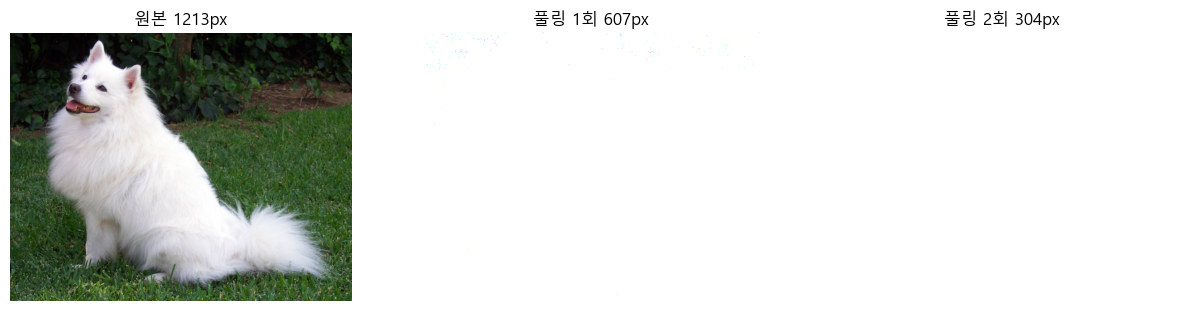

In [25]:
p1 = tf.nn.max_pool2d(img[np.newaxis].astype('float32'), ksize=2, strides=2, padding='SAME')
p2 = tf.nn.max_pool2d(p1, ksize=2, strides=2, padding='SAME')

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(img); plt.title(f'원본 {img.shape[0]}px'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(p1[0]); plt.title(f'풀링 1회 {p1.shape[1]}px'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(p2[0]); plt.title(f'풀링 2회 {p2.shape[1]}px'); plt.axis('off')
plt.show()

## 3. 손글씨 숫자 맞추기

In [26]:
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [27]:
# 6만장 중 1만장만 사용, 사진 모양을 (28,28)=>(28,28,10) 흑백사진이라 채널이 1
x_tr = x_tr[:10000, :, :, np.newaxis] / 255.0     # 1만 장만 사용(속도!)
y_tr = y_tr[:10000]
x_te = x_te[:, :, :, np.newaxis] / 255.0

In [28]:
x_tr.shape

(10000, 28, 28, 1)

In [29]:
y_tr.shape

(10000,)

In [30]:
x_te.shape

(10000, 28, 28, 1)

In [31]:
y_te.shape

(10000,)

In [32]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=(28,28,1)),  # 필터 16개
    tf.keras.layers.MaxPooling2D(),                                            # 절반 요약
    tf.keras.layers.Conv2D(32, 3, activation='relu'),                          # 필터 32개
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),                                                 # 펼치기
    tf.keras.layers.Dense(10, activation='softmax')                            # 0~9 판단
])

In [38]:
# 딥러닝 모델 만들기 위한 선형 모델 선언 => 층을 순서대로 쌓는 방식
# 입력 이미지 : Conv2D > MaxPooling2D > Conv2D > MaxPooling2D > Flatten > Dense > 최종 예측
model = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(28,28,1)),                                    # 입력 이미지 크기 지정
    
    #이미지에서 특징을 찾는 충 => 2차원 이미지에서 특징을 찾는 층
    # 16 : 필터를16개 사용, 필터는 이미지에서 특징을 찾는 작은 도구
    # 필터 1번 : 세로선 찾기, 필터 2번 : 가로선 찾기, 필터 3번 : 곡선 찾기 ....
    # 3은 3x3 크기의 필터를 사용
    # activation = relu : 중요한 특징을 잘 살리고, 불필요한 값을 0으로 만드는 역할
    tf.keras.layers.Conv2D(16, 3, activation='relu'),                          # 필터 16개
    # 이미지 특징을 작게 요약하는 층 = 이미지 크기를줄이면서 중요한 특징만 남기는 역할 
    # 예) (1,3,2,5)가 들어오면 가장 큰 값인 5만 남겨둠
    tf.keras.layers.MaxPooling2D(),                                            # 절반 요약

    # 앞에서 한번 특징을 찾았고, 더 복잡한 특징을 찾음 필터 32개 사용 
    # 앞에서 큰 윤곽으로 특징을 잡고 다음에서 더 촘촘하게 특징을 잡는게 유리
    tf.keras.layers.Conv2D(32, 3, activation='relu'),                          # 필터 32개
    # 
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),                                                 # 펼치기

    #모델이 숫자 이미지를 보고, 최종적으로 0~9 중 하나라고 판단하는 층 => 출력 결과가 10개라는 뜻
    tf.keras.layers.Dense(10, activation='softmax')                            # 0~9 판단
])

## 모델 학습을 위한 학습 방법을 설정

In [40]:
"""
optimizer : 모델이 공부하는 방법 > 모델이 틀린 답을 줄이도록 내부 값을 조정하는 방법 => 모델이 공부하는 방법
    - adam : 모델이 빠르고, 안정적으로 학습하도록 도와주는 대표적인 방법
    - sgd : 기본, 느림
loss : 모델이 얼마나 틀렸는지 계산하는 방법 > 모델의 오답 점수
    - binary_crossentropy, : 사용 상황이 둘중 하나를 분류할때
    - sparse_categorical_crossentropy, : 여러개 중에 하나를 고르는 문제 > 다중분류 + 
    - categorical_crossentropy : 정답이 숫자 하나가 아니라 원-핫 인코딩 형태일때 사용 > 다중분류 + 원-핫 라벨
        - 예를들면 7을 [0, 0, 0, 0, 0, 0, 1, 0, 0]로 표현될 때
metrics : 학습 결과를 어떤 기준으로 볼것인지의 기준
    - accuracy
    - mse
"""
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
'''
 epoch : 학습 횟수, batch_size : 한번 학습시 몇개의 데이터를 묶어서 학습할지를 정하는 값
 10000/128 = 약 78 : 전체 데이터를 한번 학습하는 동안 약 78번 정도 나누어서 학습 
 validation_split : 실제 학습에 쓰이는 
'''
hist = model.fit(x_tr, y_tr, epochs=3, batch_size=128, validation_split=0.1)
loss, acc = model.evaluate(x_te, y_te, verbose=0)
print(f'테스트 정확도: {acc*100:.1f}%')

Epoch 1/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9327 - loss: 0.2383 - val_accuracy: 0.9320 - val_loss: 0.2167
Epoch 2/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9450 - loss: 0.1900 - val_accuracy: 0.9390 - val_loss: 0.1876
Epoch 3/3
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9559 - loss: 0.1545 - val_accuracy: 0.9490 - val_loss: 0.1607
테스트 정확도: 95.6%


In [41]:
#predict
pred = model.predict(x_te[:5], verbose=0).argmax(axis=1)

In [ ]:
loss, acc = model.evaluate

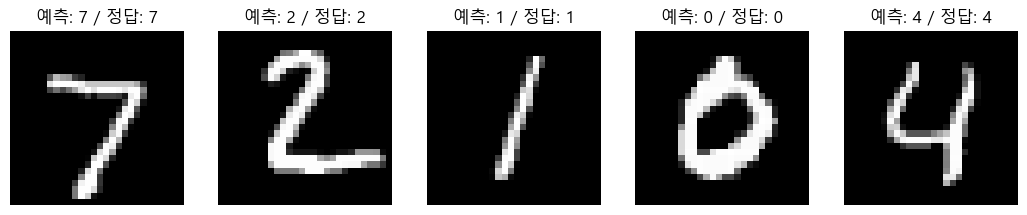

In [44]:
loss, acc = model.evaluate(x_te, y_te, verbose=0)
plt.figure(figsize=(13, 3))
plt.subplot(1,5,1)
plt.imshow(x_te[0,:,:,0], cmap='gray')
plt.title(f'예측: {pred[0]} / 정답: {y_te[0]}')
plt.axis('off')
plt.subplot(1,5,2)
plt.imshow(x_te[1,:,:,0], cmap='gray')
plt.title(f'예측: {pred[1]} / 정답: {y_te[1]}')
plt.axis('off')
plt.subplot(1,5,3) 
plt.imshow(x_te[2,:,:,0], cmap='gray'); 
plt.title(f'예측: {pred[2]} / 정답: {y_te[2]}')
plt.axis('off')
plt.subplot(1,5,4)
plt.imshow(x_te[3,:,:,0], cmap='gray')
plt.title(f'예측: {pred[3]} / 정답: {y_te[3]}')
plt.axis('off')
plt.subplot(1,5,5)
plt.imshow(x_te[4,:,:,0], cmap='gray')
plt.title(f'예측: {pred[4]} / 정답: {y_te[4]}')
plt.axis('off')
plt.show()